#   --   -- -  --  -- --- EXO1--- ---- ------ -----

# importation des bibliothèques

In [156]:
from matplotlib import pyplot as plt
from pyampute.exploration.mcar_statistical_tests import MCARTest
import pandas as pd
import seaborn as sns
import numpy as np
import missingno as msno 
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
import glob
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [157]:
sns.set_theme(rc = {"figure.figsize": (16, 8)})

### Chargement et découverte des données

In [158]:
df = pd.read_csv('Projet_ISI_M1_2025_2026.csv')
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,NaN,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [159]:
def pourcentage_valeurs_manquantes(df):
    return df.isna().mean()

In [160]:
pourcentage_valeurs_manquantes(df)

Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.010000
State            0.050000
Postal Code      0.001122
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.010000
dtype: float64

### visualiser graphiquement les valeurs manquantes dans un DataFrame.

In [161]:
def displayNaN(data):
    msno.matrix(data, (0.2, 0.5, 0.2), sparkline=False)
    plt.show()

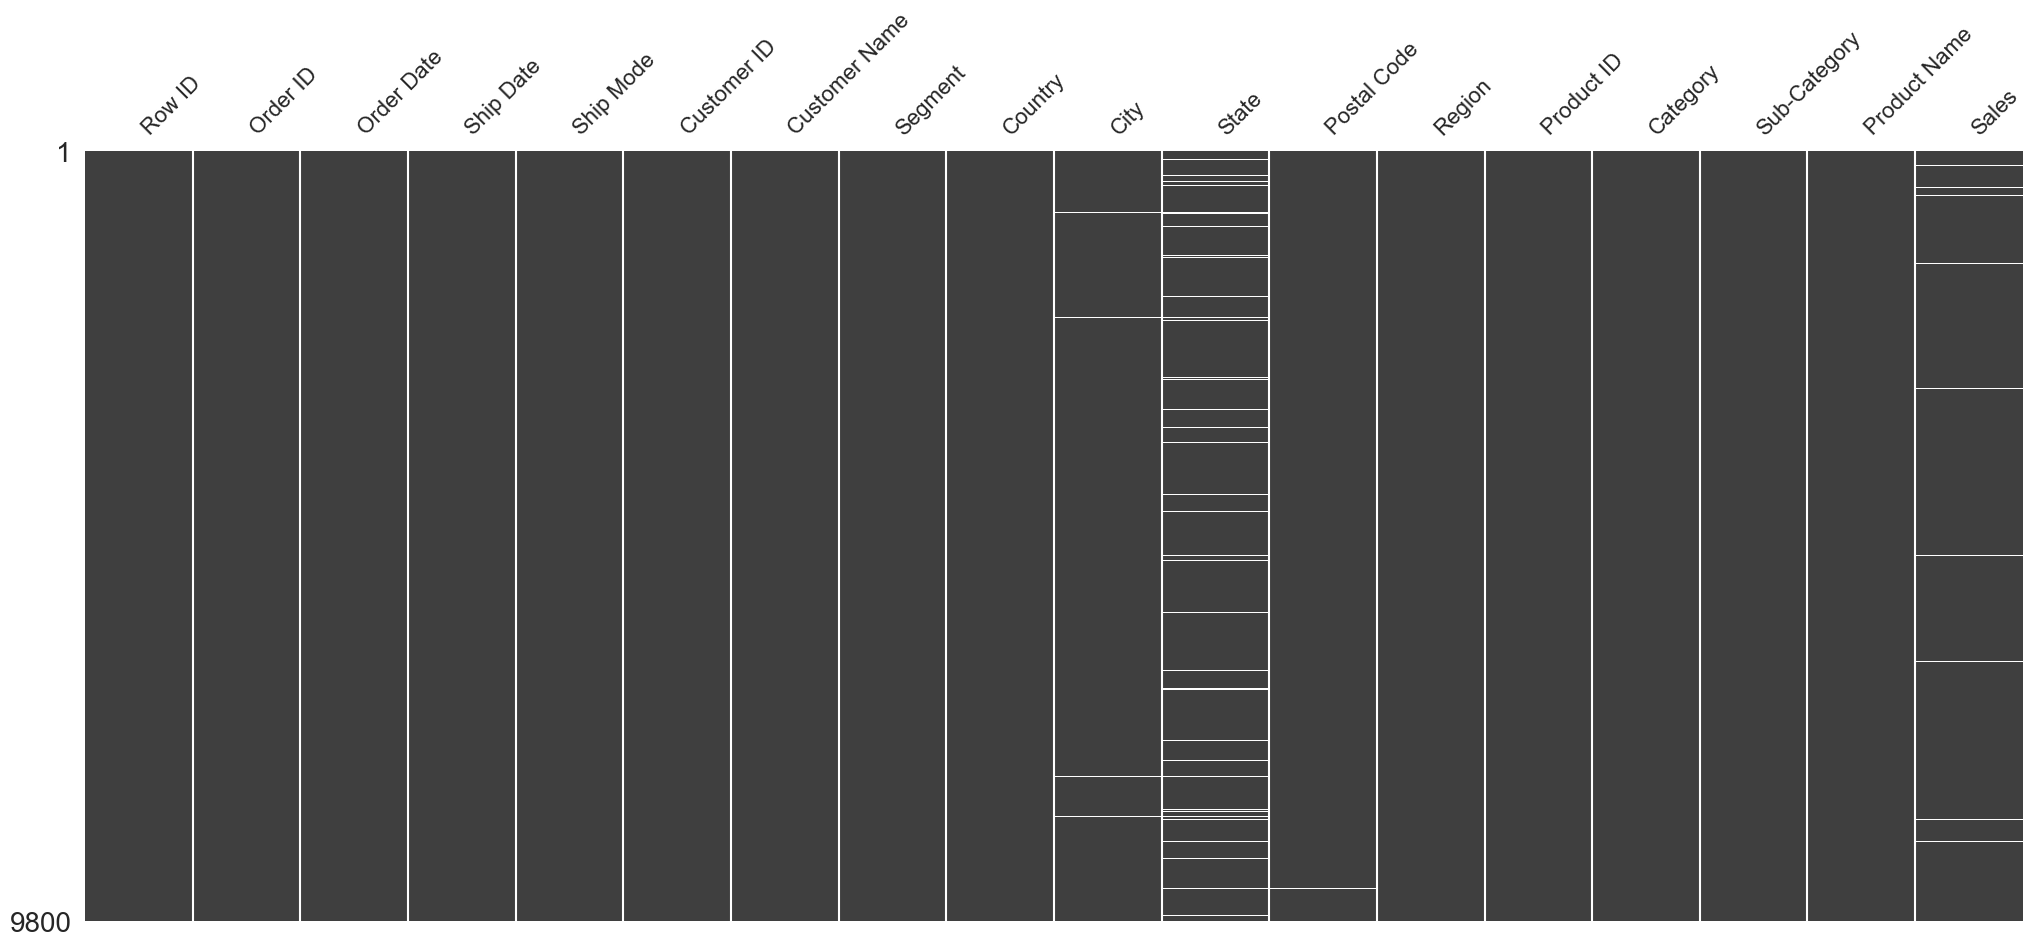

In [162]:
displayNaN(df)

---
- Listes variables qui ont des NAN

In [163]:
null_cols = df.columns[df.isna().any()]
null_cols

Index(['City', 'State', 'Postal Code', 'Sales'], dtype='str')

In [164]:
null_cols

Index(['City', 'State', 'Postal Code', 'Sales'], dtype='str')

---
-Les valeurs manquantes ne se traitent pas pareil selon le type (numérique vs catégoriel)
---
- Les vars NUMERIQUES qui ont des NaNs

In [165]:
nan_num_cols = df[null_cols].select_dtypes('number').columns
nan_num_cols

Index(['Postal Code', 'Sales'], dtype='str')

---
- Les liste des  QUALITATIVES qui ont des NaN

In [166]:
nan_cat_cols = df[null_cols].select_dtypes('str').columns
nan_cat_cols

Index(['City', 'State'], dtype='str')

In [167]:
pvalue = MCARTest().little_mcar_test(df[nan_num_cols])
if pvalue >= 0.05:
    print(f"Les valeurs sont probablement de type MCAR, car {pvalue} >= 0.05")
else:
    print(f"Les valeurs ne sont pas de type MCAR, car {pvalue} < 0.05")

Les valeurs ne sont pas de type MCAR, car 3.374467327788011e-08 < 0.05


#  1 - comme les valeurs ne sont pas de  types  MCAR alors elles sont probablement de type MNAR ou MAR

# verification 
- Les distributions, les outliers, 
- correlations

In [168]:
def dist_var(data, nrows=1, ncols=2):
    for col in data.select_dtypes('number').columns:
        _, axes = plt.subplots(nrows, ncols, figsize=(10, 4))
        sns.histplot(data[col], ax=axes[0])
        sns.boxplot(x=data[col], ax=axes[1], showmeans=True)
    plt.show()

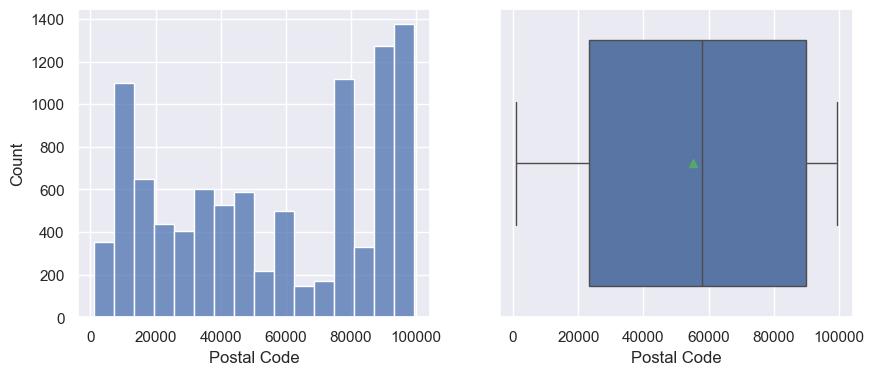

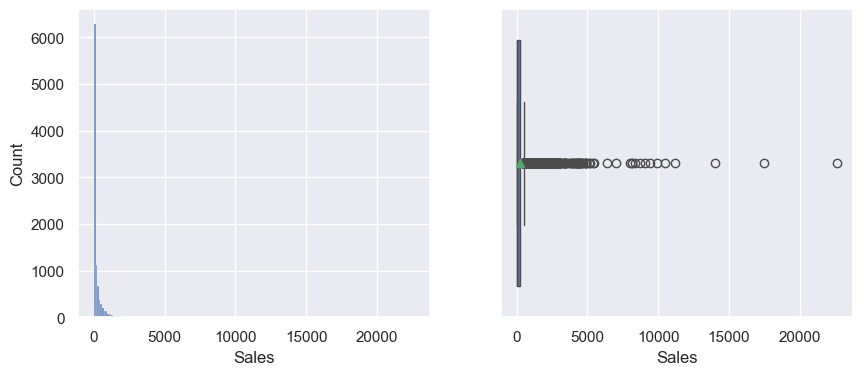

In [169]:
dist_var(data=df[nan_num_cols])

In [170]:
def correlations(data):
    plt.figure(figsize=(8, 8))
    corr_matrix = data.corr(numeric_only=True).round(3)
    sns.heatmap(corr_matrix,
                annot=True,
                cmap='viridis',
                cbar=True,
                # mask=np.triu(np.ones_like(data.corr(numeric_only=True)))
                mask=np.tril(np.ones_like(data.corr(numeric_only=True)))
                )
    plt.title("Matrice de correlation")
    plt.show()

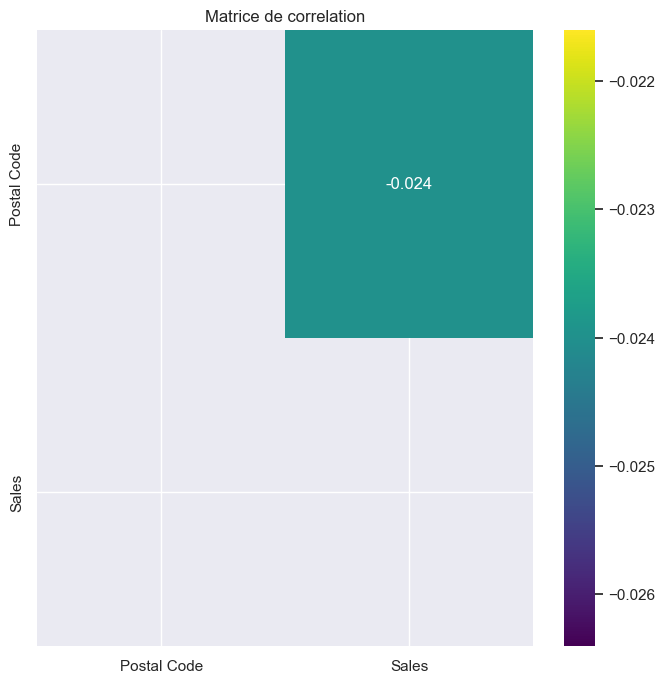

In [171]:
correlations(data=df[nan_num_cols])

# Reponses question 2: 
### les NAN peuvent etre imputer par :

Les valeurs manquantes n'étant pas MCAR (p-value < 0,05) mais étant peu nombreuses et les variables faiblement corrélées, l'imputation par la médiane a été retenue car elle est robuste aux valeurs aberrantes et a un faible impact sur la distribution des données.

# et le mode pour les variable categorielles

---
- imputation des vars num par la mediane 

In [172]:
df[nan_num_cols] = SimpleImputer(strategy='median').fit_transform(df[nan_num_cols])

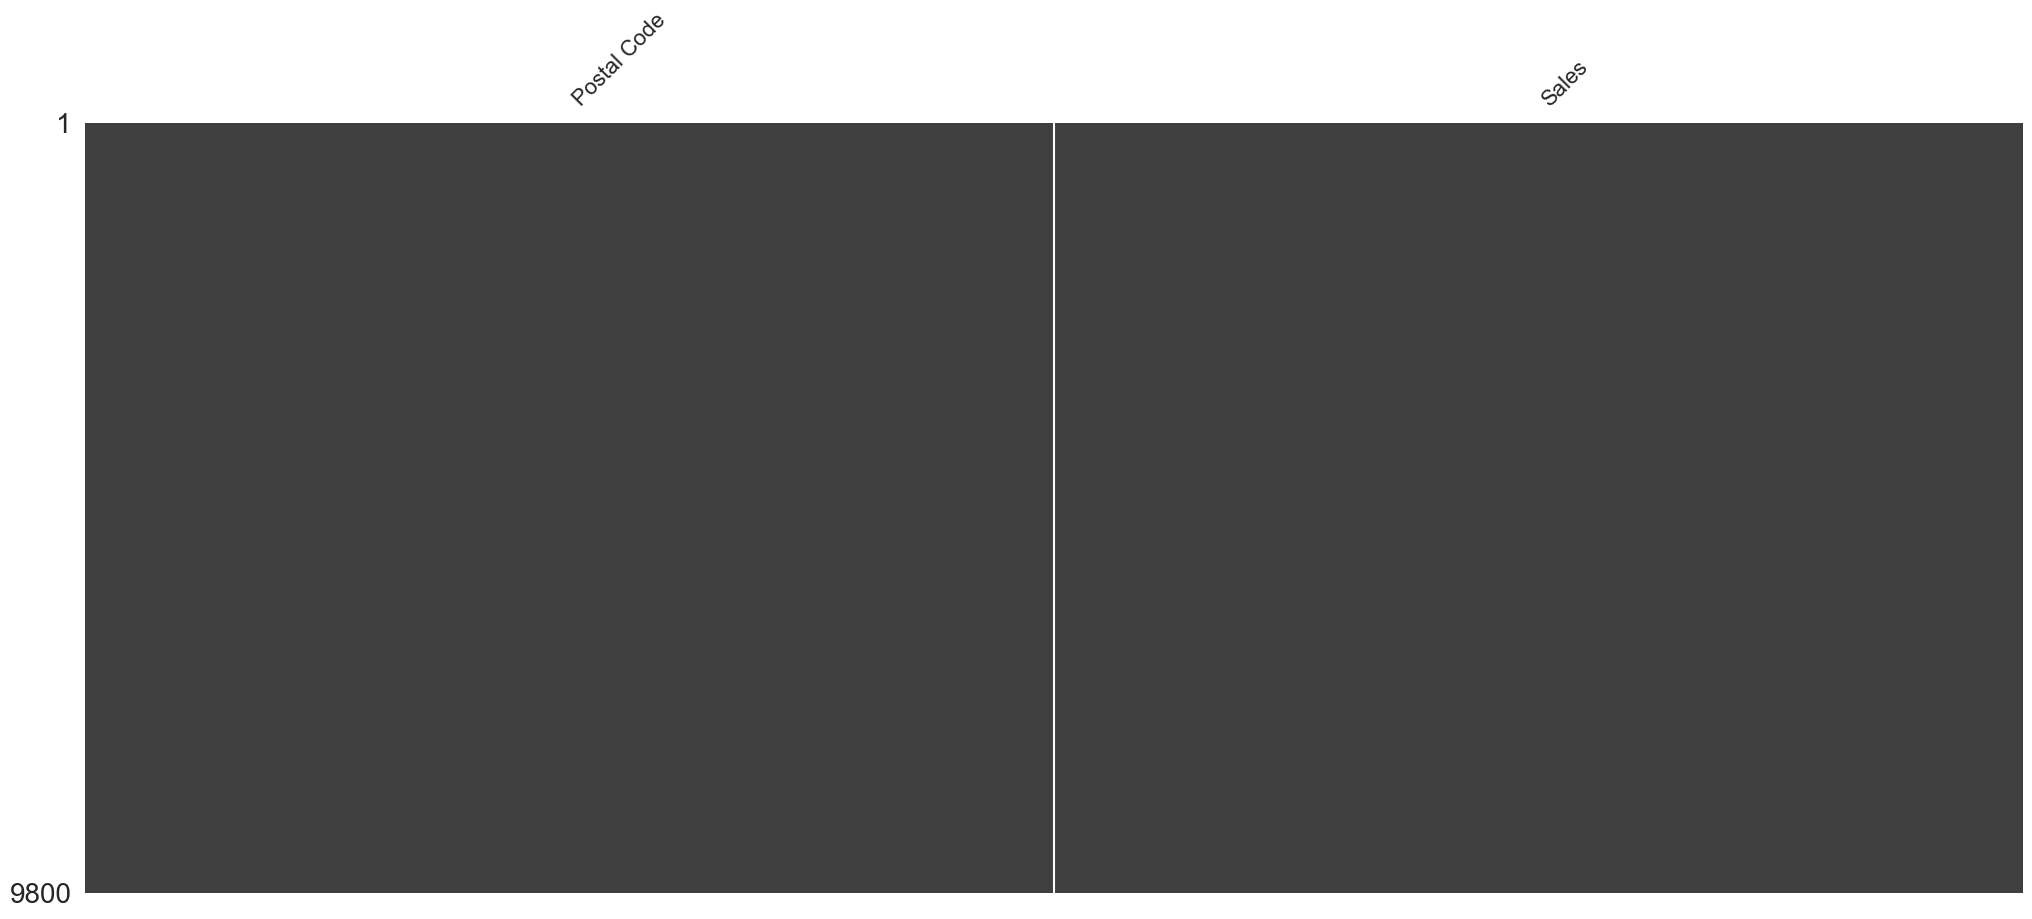

In [173]:
displayNaN(df[nan_num_cols])

In [174]:
def imputeNaNMode(data) -> pd.DataFrame:
    cat_cols = data.select_dtypes('str').columns
    # data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode()[0])
    data[cat_cols] = SimpleImputer(
        strategy='most_frequent').fit_transform(data[cat_cols])
    return data

In [175]:
df[nan_cat_cols] = imputeNaNMode(df[nan_cat_cols])

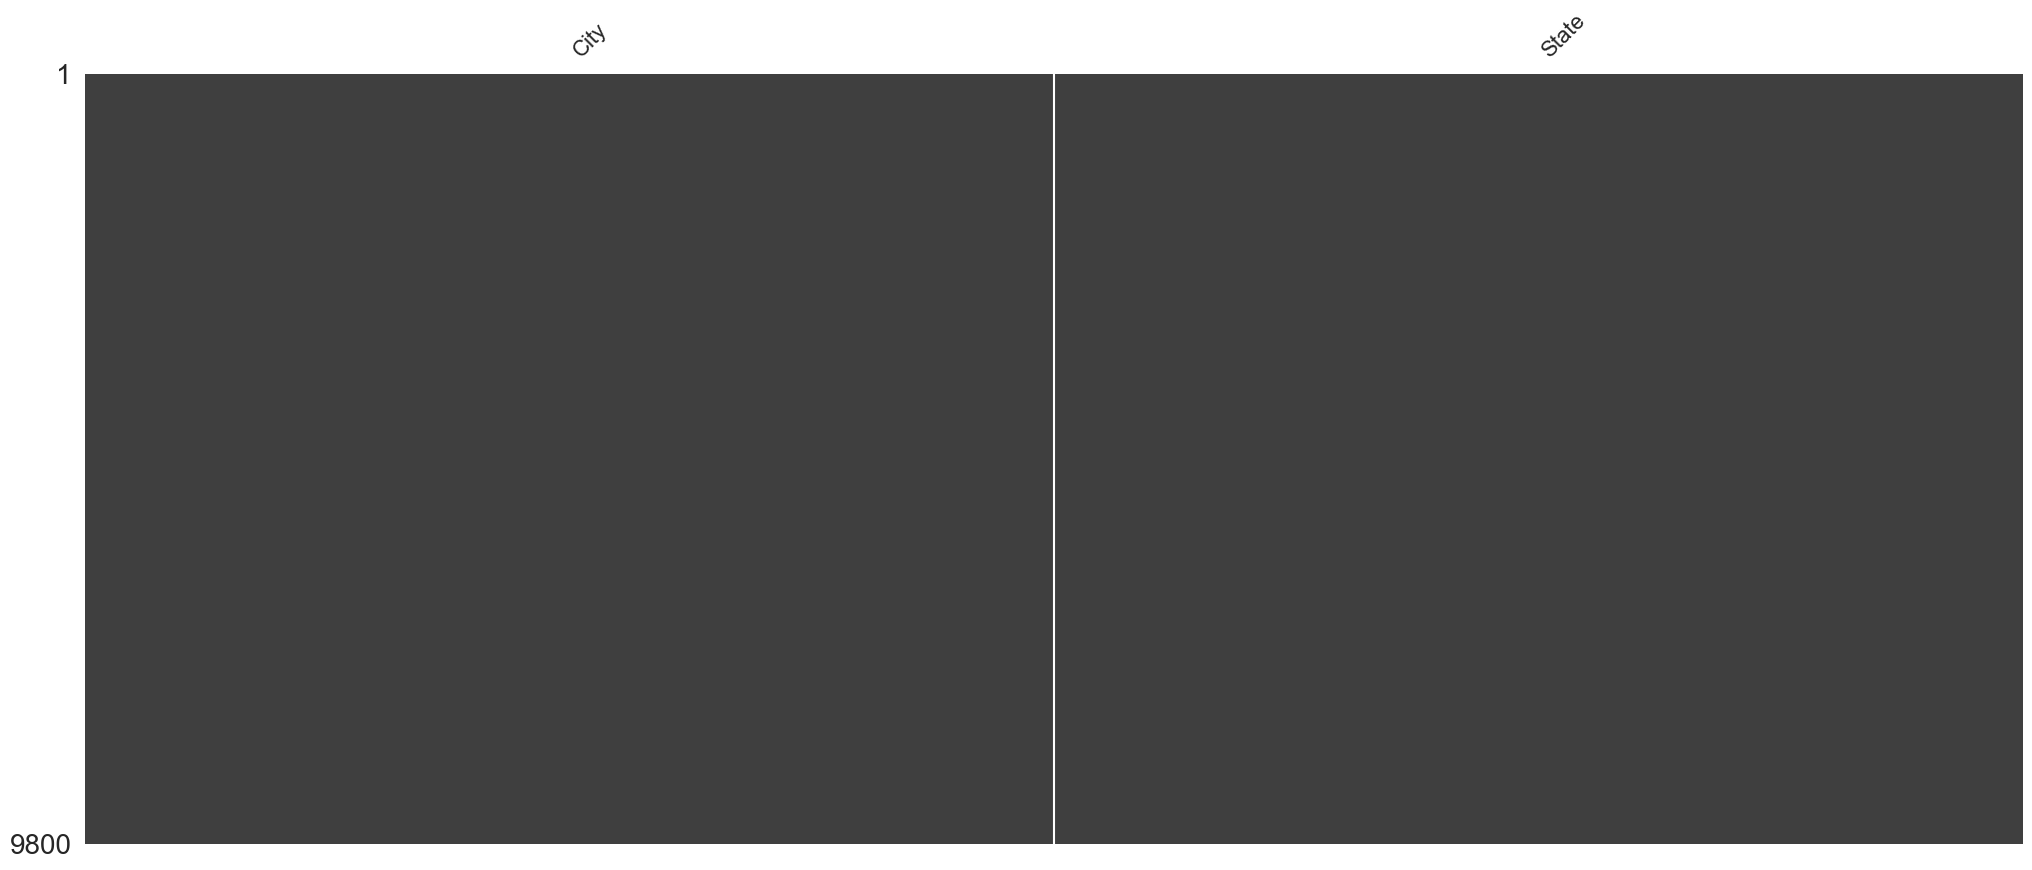

In [176]:
displayNaN(df[nan_cat_cols])

# Q3  les outliers

In [177]:
def dist_var(data, nrows=1, ncols=2):
    for col in data.select_dtypes('number').columns:
        _, axes = plt.subplots(nrows, ncols, figsize=(10, 4))
        sns.histplot(data[col], ax=axes[0])
        sns.boxplot(x=data[col], ax=axes[1], showmeans=True)
    plt.show()

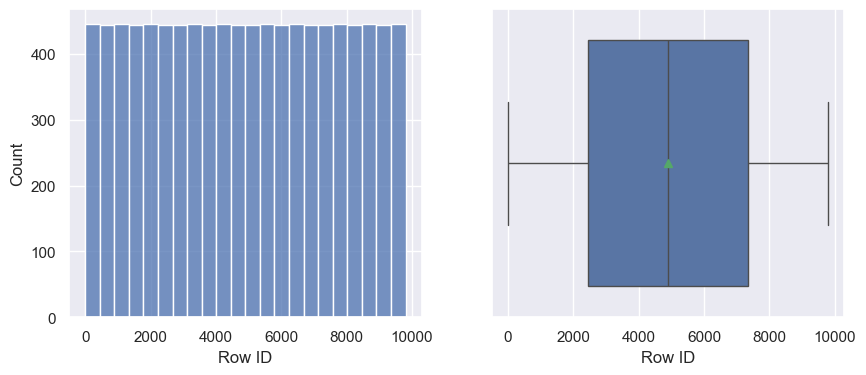

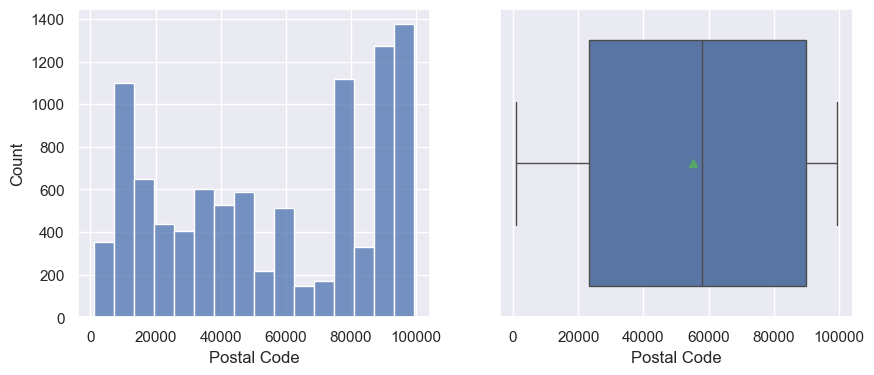

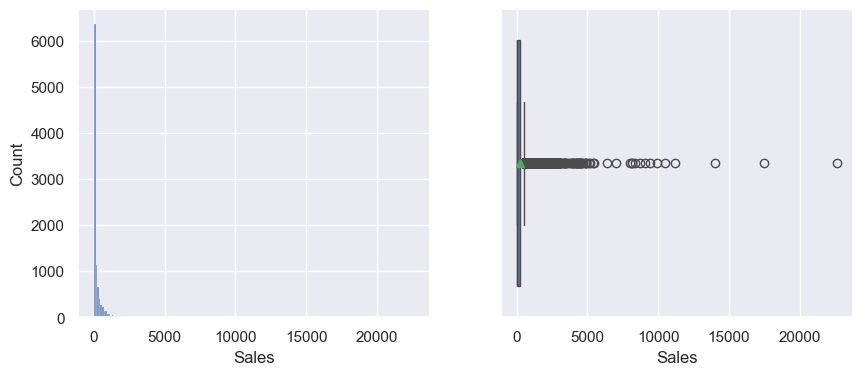

In [178]:
dist_var(df)

---
- Traitement des outliers par
Methodes : IQR

In [179]:


def imputeOutliersIQR(data: pd.DataFrame, factor=1.5) -> pd.DataFrame:
    for col in data.select_dtypes('number').columns:
        if not (-0.5 <= data[col].skew() <= 0.5):
            Q1 = np.quantile(data[col], 0.25)
            Q3 = np.quantile(data[col], 0.75)
            IQR = Q3 - Q1
            limitInf = Q1 - factor*IQR
            limitSup = Q3 + factor*IQR

            data[col] = np.where(data[col] <= limitInf, limitInf, data[col])
            data[col] = np.where(data[col] >= limitSup, limitSup, data[col])
    return data

In [180]:
outliers_vars = ['Row ID', 'Postal Code', 'Sales']

df[outliers_vars] = imputeOutliersIQR(df[outliers_vars])



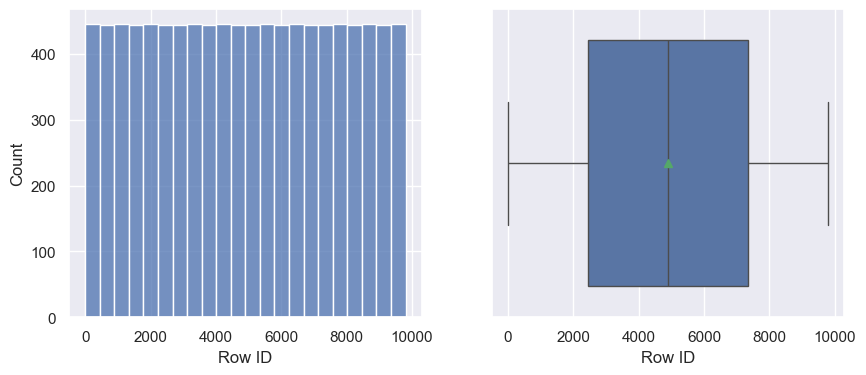

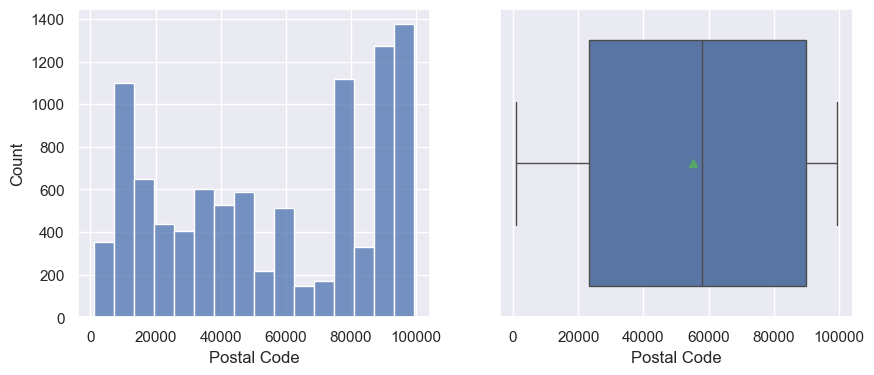

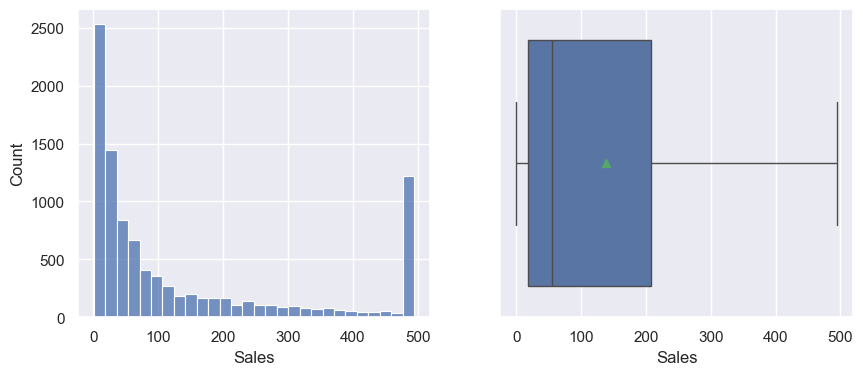

In [181]:
dist_var(df[outliers_vars])

# Q4 ENCODAGE

---
- Les variables Segment et Category sont des variables qualitatives nominales sans ordre naturel entre leurs -modalités. La méthode d'encodage la plus appropriée est donc OneHotEncoder.

In [182]:
nominale_cols = ['Segment','Category']

onehotencoder = OneHotEncoder(sparse_output=False, drop='if_binary')
onehotencoder.fit_transform(df[nominale_cols])

array([[1., 0., 0., 1., 0., 0.],
       [1., 0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 1.]], shape=(9800, 6))

In [183]:
new_columns = onehotencoder.get_feature_names_out(nominale_cols)
df[new_columns] = pd.DataFrame(onehotencoder.fit_transform(df[nominale_cols]), columns=new_columns)

In [184]:
df[new_columns] 

,Segment_Consumer,Segment_Corporate,Segment_Home Office,Category_Furniture,Category_Office Supplies,Category_Technology
0,1.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...
9795,0.0,1.0,0.0,0.0,1.0,0.0
9796,0.0,1.0,0.0,0.0,1.0,0.0
9797,0.0,1.0,0.0,0.0,0.0,1.0
9798,0.0,1.0,0.0,0.0,0.0,1.0


# Q5 mise a echelle

---
- Feature scaling pour reduire à une echelle commune des vars
    - 

In [185]:
num_cols = df.select_dtypes('number').drop(columns=
            ['Row ID', 'Postal Code', 'Segment_Consumer', 'Segment_Corporate', 'Segment_Home Office',
             'Category_Furniture', 'Category_Office Supplies', 'Category_Technology']).columns

df[num_cols] = RobustScaler().fit_transform(df[num_cols])



In [186]:
print("Variables normalisées :", num_cols.tolist())

Variables normalisées : ['Sales']


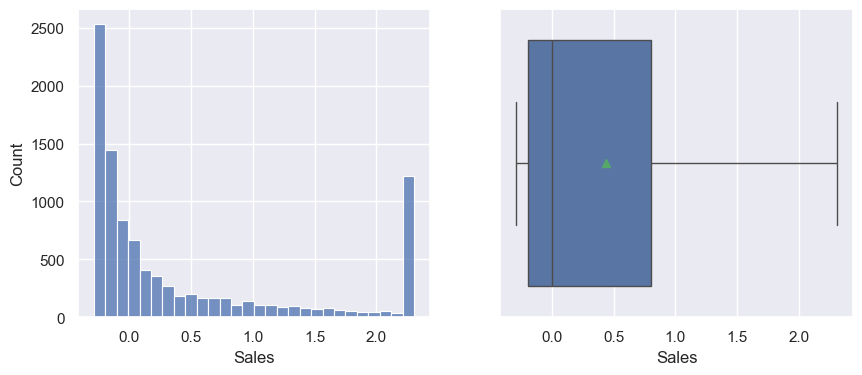

In [187]:
dist_var(df[num_cols])

---
- Les variables numériques (Postal Code et Sales) ont été normalisées avec RobustScaler après exclusion de l'identifiant Row ID, car les données ne suivent pas une distribution normale et contiennent des valeurs aberrantes.

# fin exo 1

# EXO2 (data analysis) - Examen (cours + TD + TP)

# Q1

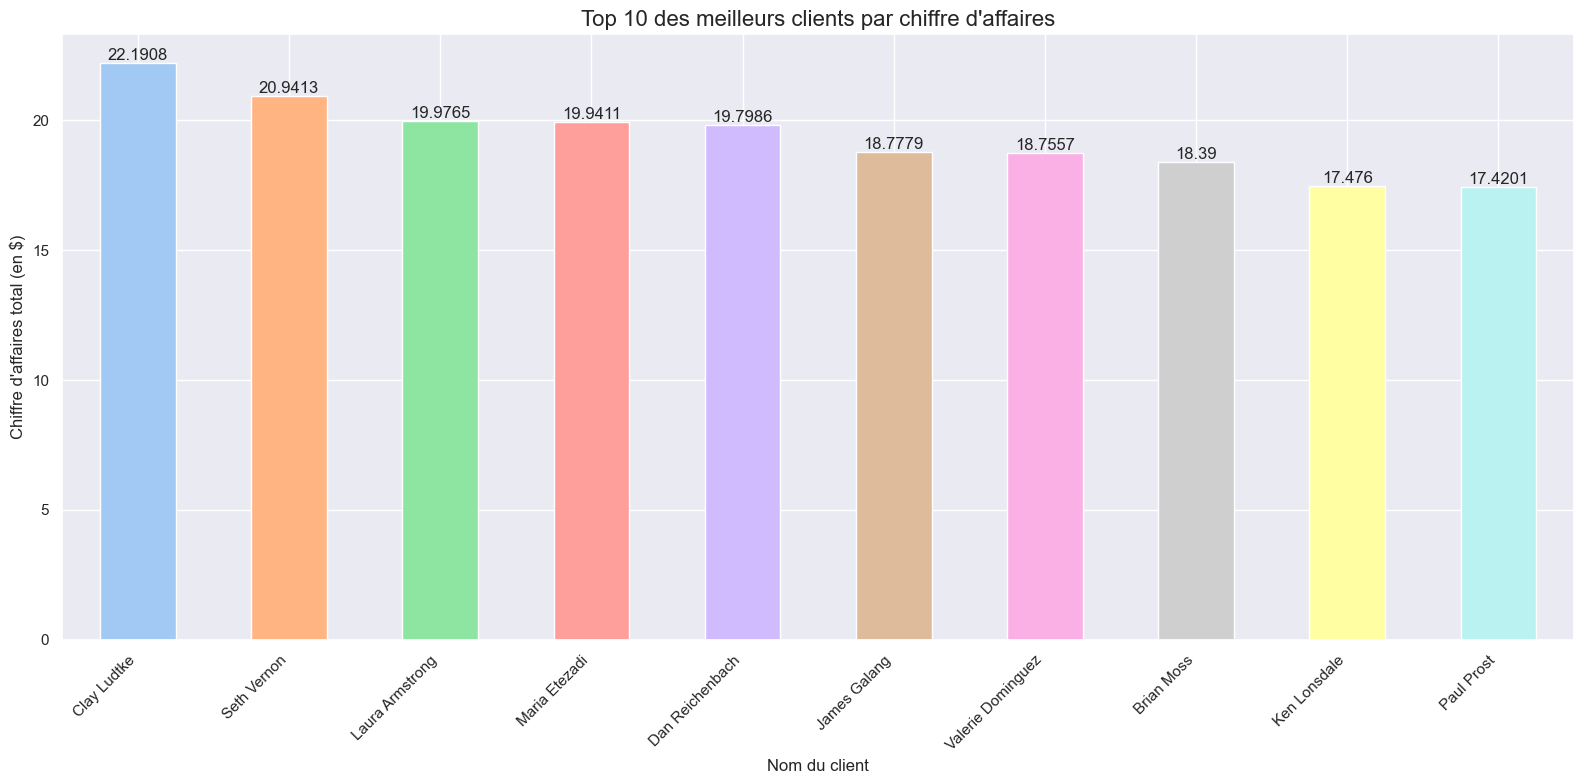

In [188]:
colors = sns.color_palette('pastel', len(df['Customer Name'].unique()))
top_clients = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
ax = top_clients.plot(kind='bar', color=colors)
for bar in ax.containers:
    ax.bar_label(bar)
plt.title('Top 10 des meilleurs clients par chiffre d\'affaires', fontsize=16)
plt.xlabel('Nom du client', fontsize=12)
plt.ylabel('Chiffre d\'affaires total (en $)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Interprétation :**
- **Clay Lulcke** est le meilleur client avec un CA de **22 190.80 **.
- Les 10 premiers clients génèrent des montants **relativement proches** (entre 17 000 et 22 000 ), ce qui indique une **clientèle fidèle** et un panier moyen homogène.
- Aucun client ne surpasse les autres de manière exceptionnelle → **pas de dépendance excessive** vis-à-vis d'un seul client.

**Conclusion :** L'entreprise dispose d'une base de clients solides. Une stratégie de **fidélisation** sur ces 10 clients pourrait stabiliser encore davantage le chiffre d'affaires.

# Q2

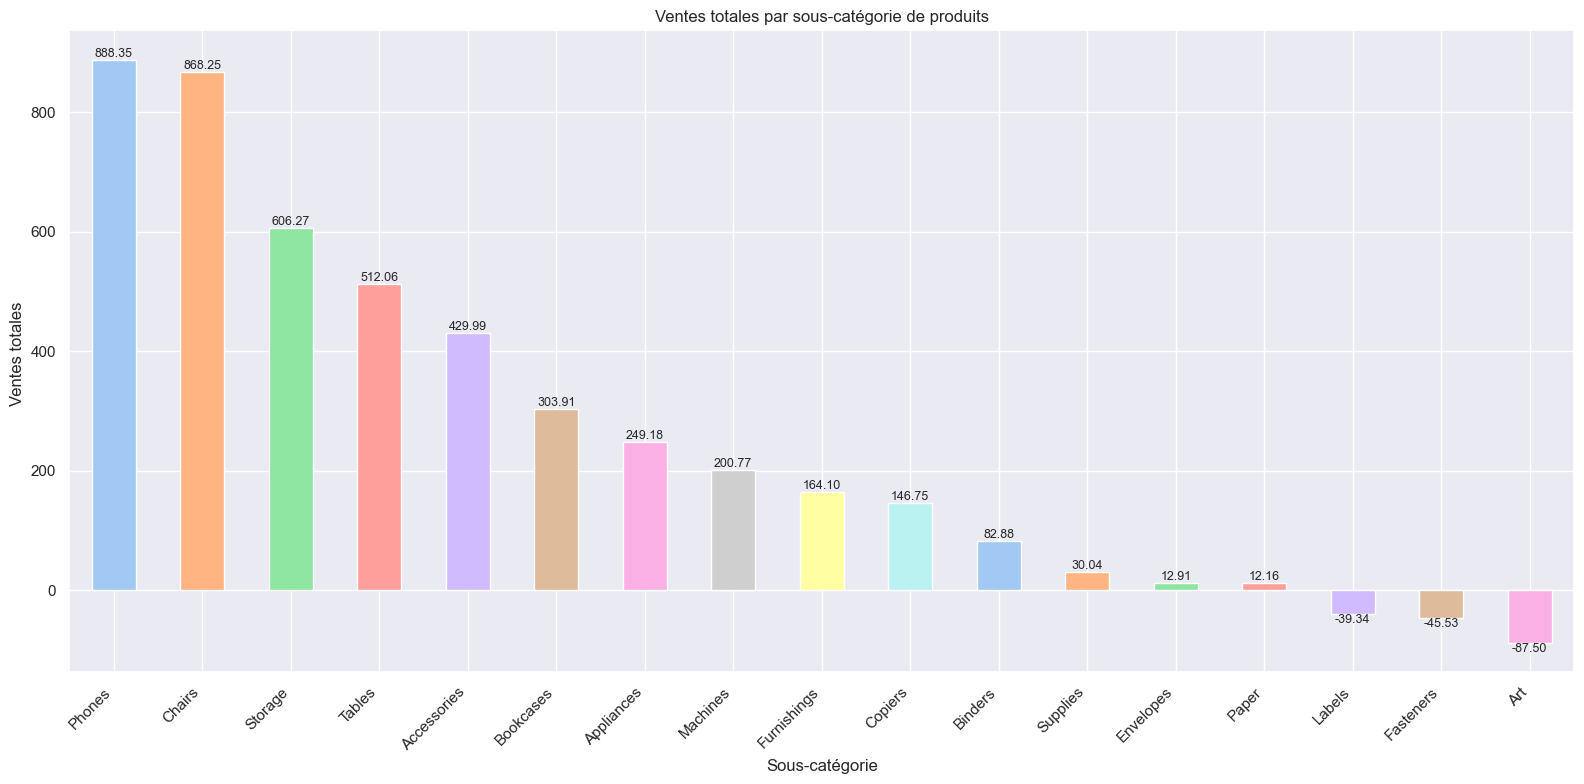

In [189]:

top_subcategory = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)


colors = sns.color_palette('pastel', len(top_subcategory))
ax = top_subcategory.plot(kind='bar', color=colors)
for bar in ax.containers:
    ax.bar_label(bar, fmt='%.2f', fontsize=9)
plt.title('Ventes totales par sous-catégorie de produits')
plt.xlabel('Sous-catégorie')
plt.ylabel('Ventes totales ')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Interprétation :**
- La sous-catégorie **Phones** est la plus vendue avec **888.35 **, suivie de près par **Chairs** (868.25 ).
- On observe des **valeurs négatives** pour certaines sous-catégories (`Labels`, `Fasteners`, `AI`). Cela peut indiquer :
  - Des **remboursements** ou **annulations**,
  - Des **erreurs de saisie**,
  - Des **retours produits**.
- Ces valeurs négatives devront être **traitées** (vérifiées ou corrigées) avant toute modélisation.

# Q3

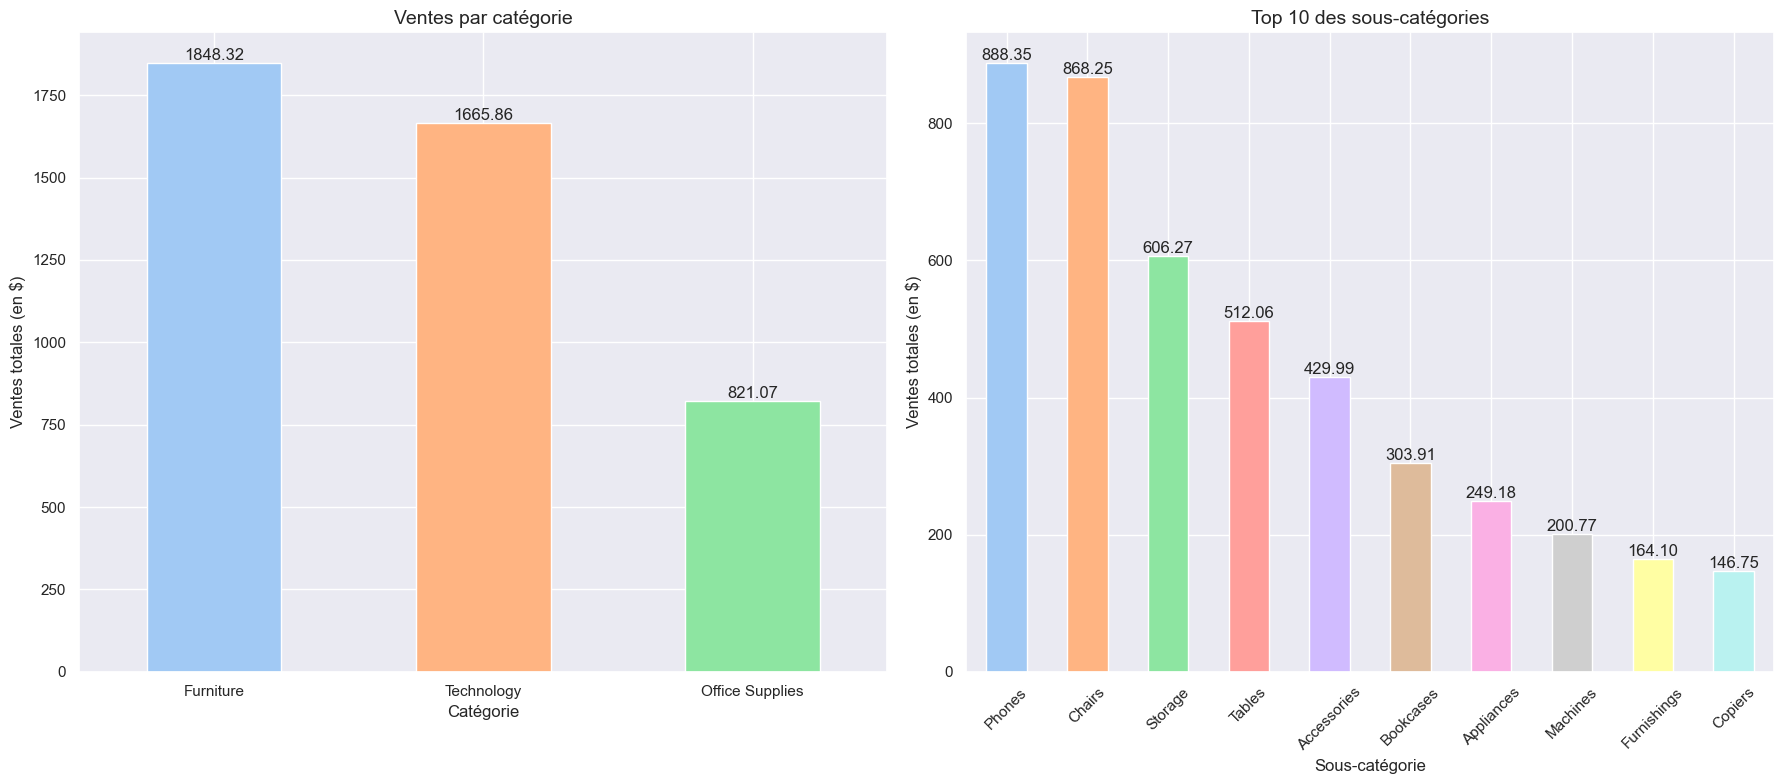

In [190]:

cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)


subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)


fig, axes = plt.subplots(1, 2, figsize=(18, 8))


colors_cat = sns.color_palette('pastel', len(cat_sales))
ax1 = cat_sales.plot(kind='bar', ax=axes[0], color=colors_cat)
for bar in ax1.containers:
    ax1.bar_label(bar, fmt='%.2f')
ax1.set_title('Ventes par catégorie', fontsize=14)
ax1.set_xlabel('Catégorie')
ax1.set_ylabel('Ventes totales (en $)')
ax1.tick_params(axis='x', rotation=0)


colors_sub = sns.color_palette('pastel', len(subcat_sales))
ax2 = subcat_sales.plot(kind='bar', ax=axes[1], color=colors_sub)
for bar in ax2.containers:
    ax2.bar_label(bar, fmt='%.2f')
ax2.set_title('Top 10 des sous-catégories', fontsize=14)
ax2.set_xlabel('Sous-catégorie')
ax2.set_ylabel('Ventes totales (en $)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Interprétation :**
- **Furniture** est la catégorie qui génère le plus de ventes (1 848.32 ), devant **Technology** (1 665.86 ) et **Office Supplies** (821.07 ).
- Au sein de la catégorie Furniture, ce sont les **sous-catégories** `Chairs` (868.25) et `Tables` (512.06) qui tirent les performances.
- Dans **Technology**, la sous-catégorie `Phones` (888.35) domine largement.

# Q4 

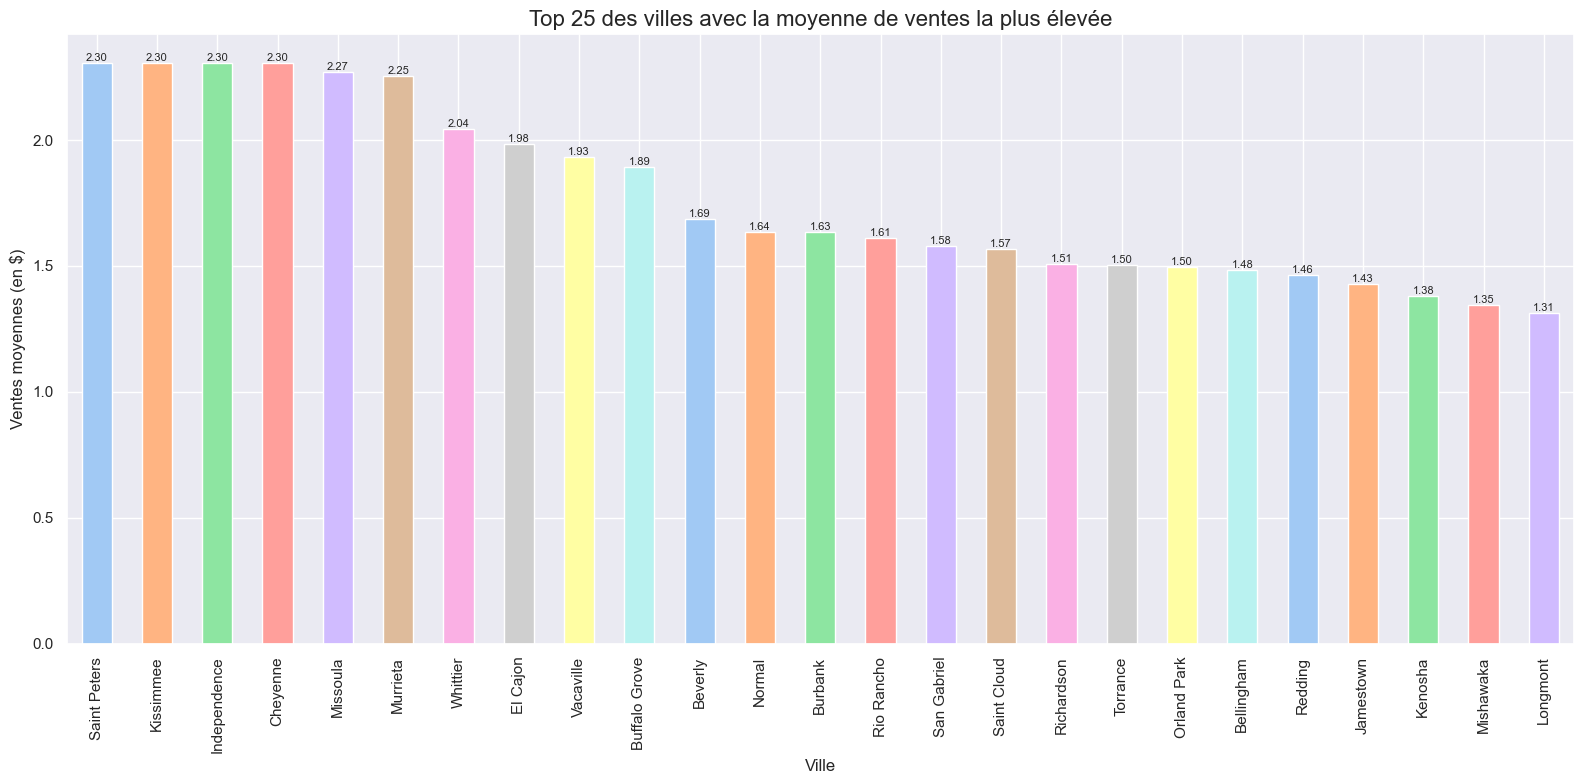

In [191]:
top_cities = df.groupby('City')['Sales'].mean().sort_values(ascending=False).head(25)


colors = sns.color_palette('pastel', len(top_cities))
ax = top_cities.plot(kind='bar', color=colors)
for bar in ax.containers:
    ax.bar_label(bar, fmt='%.2f', fontsize=8)
plt.title('Top 25 des villes avec la moyenne de ventes la plus élevée', fontsize=16)
plt.xlabel('Ville', fontsize=12)
plt.ylabel('Ventes moyennes (en $)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Interprétation :**
- Les moyennes de ventes par ville sont **très faibles** (entre 1,31  et 2,30 ). Cela peut indiquer :
  - Une **forte dispersion** des commandes,
  - Des **montants unitaires très bas**,
  - Une **clientèle essentiellement locale**.
- Les villes du top 25 sont **très proches** en termes de performance, sans véritable champion.

# Q5

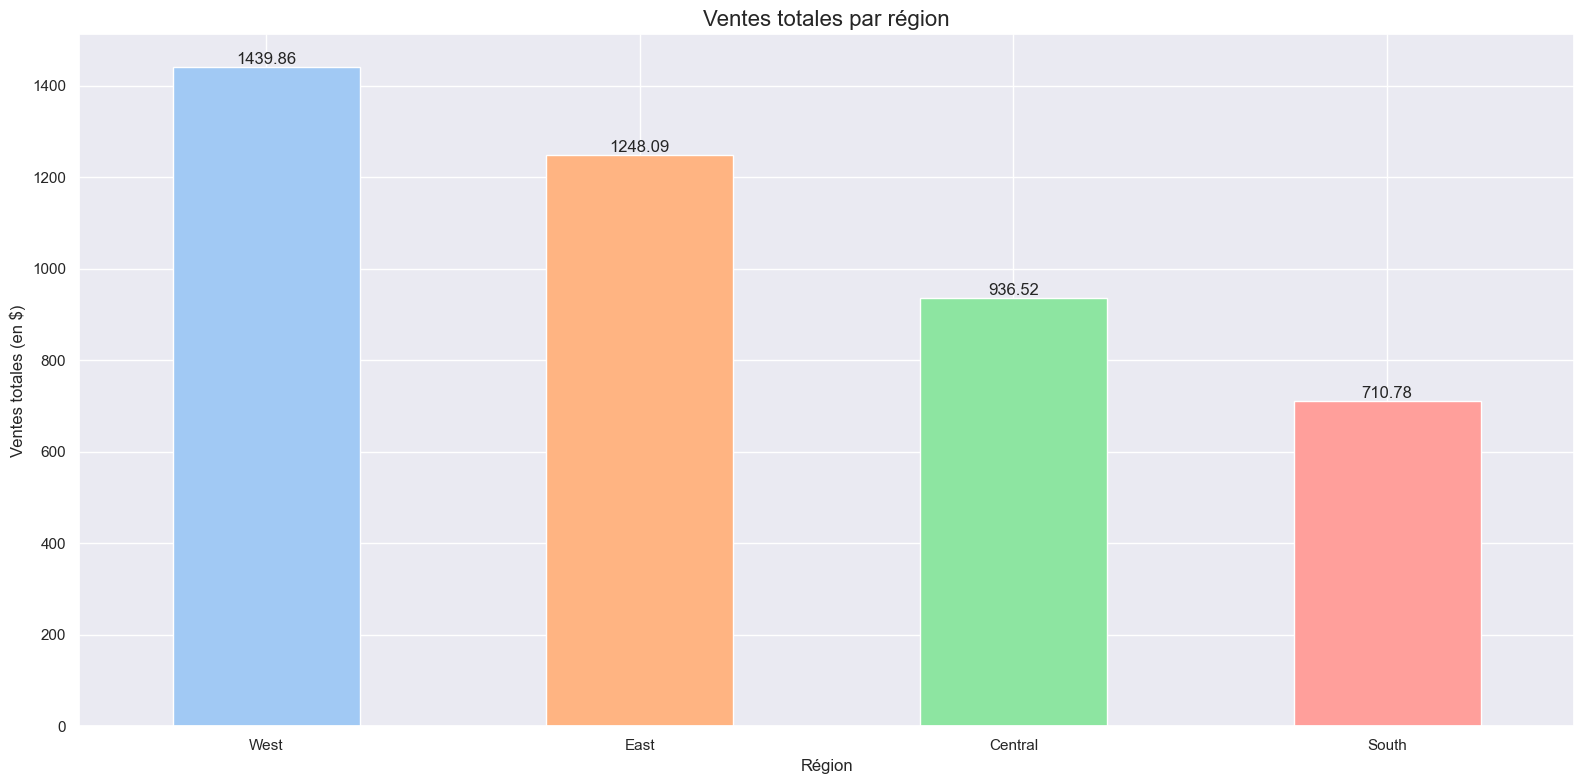

In [192]:

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)


colors = sns.color_palette('pastel', len(region_sales))
ax = region_sales.plot(kind='bar', color=colors)
for bar in ax.containers:
    ax.bar_label(bar, fmt='%.2f')
plt.title('Ventes totales par région', fontsize=16)
plt.xlabel('Région', fontsize=12)
plt.ylabel('Ventes totales (en $)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interprétation :**
- La région **West** est la plus performante avec **1 439.86 **, devant **East** (1 248.09 ), **Central** (936.52 ) et **South** (710.78 ).
- La région **South** est la moins performante, avec un écart important par rapport à West (presque le double).

# Q6

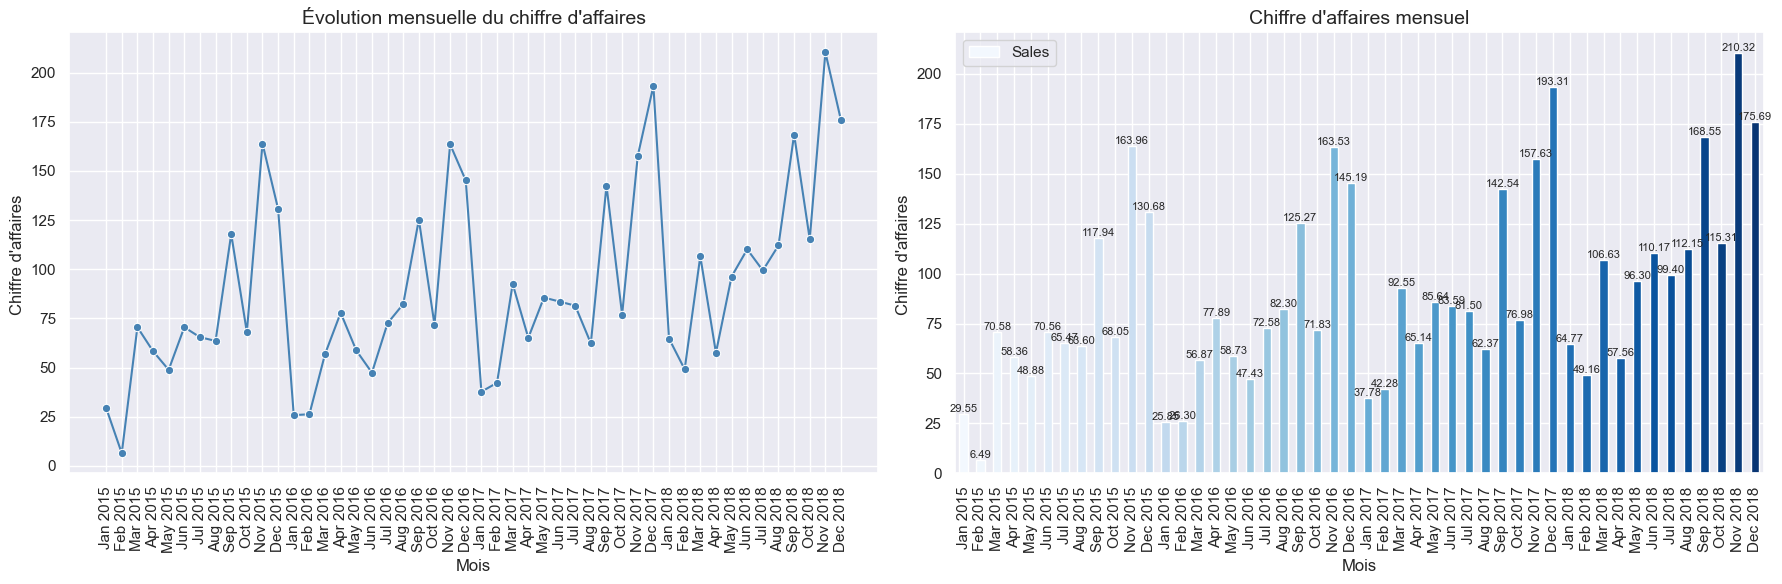

In [193]:

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')


df['Month'] = df['Order Date'].dt.strftime('%b %Y')


monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

monthly_sales['Order Date'] = pd.to_datetime(monthly_sales['Month'], format='%b %Y')
monthly_sales = monthly_sales.sort_values('Order Date')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))


ax1 = sns.lineplot(x='Month', y='Sales', data=monthly_sales, marker='o', ax=axes[0], color='steelblue')
axes[0].set_title('Évolution mensuelle du chiffre d\'affaires', fontsize=14)
axes[0].set_xlabel('Mois', fontsize=12)
axes[0].set_ylabel('Chiffre d\'affaires ', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)


colors = sns.color_palette('Blues', len(monthly_sales))
ax2 = monthly_sales.plot(kind='bar', x='Month', y='Sales', ax=axes[1], color=colors)
for bar in ax2.containers:
    ax2.bar_label(bar, fmt='%.2f', fontsize=8)
axes[1].set_title('Chiffre d\'affaires mensuel', fontsize=14)
axes[1].set_xlabel('Mois', fontsize=12)
axes[1].set_ylabel('Chiffre d\'affaires ', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()



**Interprétation :**
- On observe une **tendance générale à la hausse** entre 2016 et 2018.
- Le **pic** le plus élevé se situe en **Novembre 2018** avec **210.32 **.
- Les mois de fin d'année (Novembre, Décembre) semblent particulièrement dynamiques, probablement liés aux **périodes de fêtes** (Black Friday, Noël).
- Il existe une **saisonnalité** marquée, avec des creux en début d'année.

# Q7

In [194]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

In [195]:


class NaNTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, strategy='most_frequent', n_neighbors=5, max_iter=10):
        self.strategy = strategy
        self.n_neighbors = n_neighbors
        self.max_iter = max_iter

    def fit(self, data, y=None):
        return self
    
    def transform(self, data):
        if isinstance(data, np.ndarray):
            data = pd.DataFrame(data)

        num_cols = data.select_dtypes(['number']).columns
        cat_cols = data.select_dtypes(['str']).columns

        if self.strategy == "knn":
            data[num_cols] = KNNImputer(n_neighbors=self.n_neighbors).fit_transform(data[num_cols])
        elif self.strategy == "iterative":
            data[num_cols] = IterativeImputer(max_iter=self.max_iter).fit_transform(data[num_cols])
        elif self.strategy == "median":  
            data[num_cols] = SimpleImputer(strategy='median').fit_transform(data[num_cols])
        elif self.strategy == "most_frequent":
            data[cat_cols] = SimpleImputer(strategy=self.strategy).fit_transform(data[cat_cols])
        else:
            raise ValueError(
                f"{self.strategy} invalide, choisissez parmi 'knn','iterative','median','most_frequent' "
            )
        return data




class OutlierTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, method='iqr', factor=1.5, threshold=2):
        self.method = method
        self.factor = factor
        self.threshold = threshold

    def fit(self, data, y=None):
        return self

    def transform(self, data):
        if isinstance(data, np.ndarray):
            data = pd.DataFrame(data)

        for col in data.select_dtypes(include=['number']).columns:
            if not (-0.5 <= data[col].skew() <= 0.5):
                if self.method == "iqr":
                    data[col] = self.imputeOutliersIQR(data[col])
                elif self.method == "winsor":
                    data[col] = self.imputeOutliersWinsor(data[col])
                else:
                    raise ValueError(f"{self.method} invalide, choisissez parmi 'iqr','winsor', ... ")
        return data

    def imputeOutliersIQR(self, col):
        Q1 = np.percentile(col, 25)
        Q3 = np.percentile(col, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - self.factor * IQR
        upper_bound = Q3 + self.factor * IQR
        return np.clip(col, lower_bound, upper_bound)

    def imputeOutliersWinsor(self, col):
        lower_percentile = np.percentile(col, 5) 
        upper_percentile = np.percentile(col, 95)
        return np.clip(col, lower_percentile, upper_percentile)



---
- . PIPELINES AVEC LES BONNES STRATÉGIES

In [196]:

numerical_features = ['Sales']
nominal_features = ['Segment', 'Category', 'Ship Mode', 'Region', 'City', 'State']
ordinal_features = ['Sub-Category']


numerical_pipeline = Pipeline(steps=[
    ('imputer', NaNTransformer(strategy='median')),  
    ('outlier', OutlierTransformer(method="iqr")),
    ('scaler', RobustScaler()),
])


nominal_pipeline = Pipeline(steps=[
    ('imputer', NaNTransformer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])


ordinal_pipeline = Pipeline(steps=[
    ('imputer', NaNTransformer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num_pipeline', numerical_pipeline, numerical_features),
    ('nominal_pipeline', nominal_pipeline, nominal_features),
    ('ordinal_pipeline', ordinal_pipeline, ordinal_features)
])

pipe = Pipeline(steps=[('prep', preprocessor)])


---
- APPLICATION NUMÉRIQUE

In [197]:

data = df.copy()
cols_to_process = numerical_features + nominal_features + ordinal_features
X = data[cols_to_process]

X_transformed = pipe.fit_transform(X)


encoder_nominal = pipe.named_steps['prep'].named_transformers_['nominal_pipeline'].named_steps['encoder']
nominal_encoded_cols = encoder_nominal.get_feature_names_out(nominal_features)
ordinal_encoded_cols = ordinal_features

final_cols = numerical_features + list(nominal_encoded_cols) + ordinal_encoded_cols
df_processed = pd.DataFrame(X_transformed, columns=final_cols)

other_cols = ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 
              'Customer ID', 'Customer Name', 'Country', 
              'Product ID', 'Product Name', 'Postal Code',
              'Segment_Consumer', 'Segment_Corporate', 'Segment_Home Office',
              'Category_Furniture', 'Category_Office Supplies', 'Category_Technology']

for col in other_cols:
    if col in data.columns:
        df_processed[col] = data[col].values

print(f"Shape : {df_processed.shape}")

Shape : (9800, 604)


In [198]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...), ('nominal_pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

### Pipeline de prétraitement automatisé

Une solution basée sur les classes `NaNTransformer` et `OutlierTransformer` a été implémentée pour automatiser les étapes de prétraitement.


# Q8 

In [199]:
pipe = Pipeline(steps=[('prep', preprocessor)]).fit_transform(data)
pipe

array([[ 1.08629261,  1.        ,  0.        , ...,  0.        ,
         0.        ,  4.        ],
       [ 2.3041741 ,  1.        ,  0.        , ...,  0.        ,
         0.        ,  5.        ],
       [-0.21071841,  0.        ,  1.        , ...,  0.        ,
         0.        , 10.        ],
       ...,
       [ 0.94590456,  0.        ,  1.        , ...,  0.        ,
         0.        , 13.        ],
       [-0.14907184,  0.        ,  1.        , ...,  0.        ,
         0.        , 13.        ],
       [-0.23293131,  0.        ,  1.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(9800, 594))

In [200]:

print(type(pipe))   
print(pipe.shape)

<class 'numpy.ndarray'>
(9800, 594)


In [201]:

df_processed = pd.DataFrame(pipe)  
df_processed.to_csv('data_processed.csv', index=False)



# FIN  du PROJET 